# 03 - Inventory decision layer (Phase 4)

**Question:** do adaptive forecasts lead to better inventory outcomes (fill rate, stockouts, inventory held, cost) than static forecasts?

**Policy (simulated on the 168 eval days, 2015-12-07 to 2016-05-22):** daily review, reorder point with lost sales.
* End of each day: ROP = forecast demand over the next L days + safety stock; if on-hand + on-order â‰¤ ROP, order up to ROP + 7 days of forecast demand. Orders arrive L days later.
* Forecasts: the one issued at the latest origin (no lookahead). The forecasting model is the best static model from notebook 02, compared in its static and adaptive variants; seasonal naive is a benchmark.
* Safety stock is re-estimated at each origin from **past** forecast errors only (the warm-up origin seeds the first window):
  * regular items: normal formula SS = z Â· Ïƒ_daily Â· âˆšL (assumes independent daily errors)
  * intermittent items (ADI > 1.32): empirical service-level quantile of past L-day error sums

**ASSUMPTIONS (not data), varied in the sensitivity analysis**

| parameter | base | sensitivity |
|---|---|---|
| lead time L | 7 days | 3, 14 |
| annual holding cost | 25% of unit price | 15%, 35% |
| stockout cost per lost unit | 0.5 Ã— unit price | 0.25, 1, 2 Ã— |
| ordering cost | 0 (ignored) | â€“ |
| unit value | CA median sell price that week | â€“ |

Service level here is the z-target used to size safety stock (90 / 95 / 99%); the achieved **fill rate** is measured separately.

In [1]:
import sys
sys.path.append('../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from break_detection import weekly_ca_prices
from forecasting import is_intermittent
from inventory import (safety_stock_normal, safety_stock_empirical, lead_time_error_sums,
                       simulate_policy, policy_kpis)
from metrics import paired_test

SERVICE_LEVELS = [0.90, 0.95, 0.99]
LEAD_TIMES = [3, 7, 14]
BASE_L, BASE_H, BASE_M = 7, 0.25, 0.5
HOLDING_RATES = [0.15, 0.25, 0.35]
STOCKOUT_MULTIPLES = [0.25, 0.5, 1.0, 2.0]
REVIEW_DAYS = 7

In [2]:
fc = pd.read_parquet("../data/processed/backtest_forecasts.parquet")
mase_tbl = pd.read_csv("../outputs/tables/model_mase_by_category.csv", index_col='category')
MODEL = mase_tbl.loc['ALL', ['ets', 'lightgbm']].idxmin()
print(f"Forecast model for the policy (lowest median static MASE): {MODEL}")

ORIGINS = sorted(fc['origin'].unique())
EVAL_ORIGINS = ORIGINS[1:]
POLICIES = [(MODEL, 'static'), (MODEL, 'adaptive'), ('seasonal_naive', 'static')]

long_df = pd.concat([pd.read_csv(f"../data/interim/{c}_candidates.csv", parse_dates=['date'])
                     for c in ['foods', 'hobbies', 'household']], ignore_index=True)
intermittent = {item: is_intermittent(g.loc[g['date'] <= ORIGINS[0], 'sales'])
                for item, g in long_df.groupby('item_id')}

calendar = pd.read_csv("../data/raw/calendar.csv", parse_dates=['date'])
prices = pd.read_csv("../data/raw/sell_prices.csv", dtype={'store_id': 'category'})
price_wk = weekly_ca_prices(prices, calendar, long_df['item_id'].unique())
del prices

eval_days = pd.date_range(EVAL_ORIGINS[0] + pd.Timedelta(days=1), periods=28 * len(EVAL_ORIGINS))
week_start = eval_days - pd.to_timedelta((eval_days.dayofweek - 5) % 7, unit='D')
price_daily = price_wk.ffill().reindex(week_start)
price_daily.index = eval_days

breaks = pd.read_csv("../data/processed/breaks_by_origin.csv", parse_dates=['origin'])
break_item = breaks[breaks['origin'].isin(EVAL_ORIGINS)].groupby('item_id')['has_break'].any()
print(f"{len(eval_days)} eval days, {fc['item_id'].nunique()} items, intermittent: {sum(intermittent.values())}, "
      f"items with a break at some eval origin: {break_item.sum()}")

Forecast model for the policy (lowest median static MASE): lightgbm


168 eval days, 726 items, intermittent: 26, items with a break at some eval origin: 488


## Simulate every item Ã— policy Ã— service level Ã— lead time

In [3]:
fc_sub = fc[fc.set_index(['model', 'variant']).index.isin(POLICIES)]
kpi_rows, daily_rows = [], []
for (item, model, variant), g in fc_sub.groupby(['item_id', 'model', 'variant']):
    g = g.sort_values(['origin', 'date'])
    ev = g[g['origin'].isin(EVAL_ORIGINS)]
    demand = ev['actual'].to_numpy()
    window_fcs = [w['forecast'].to_numpy() for _, w in ev.groupby('origin')]
    errors_by_origin = {o: w['error'].to_numpy() for o, w in g.groupby('origin')}
    price = price_daily[item].to_numpy()
    for L in LEAD_TIMES:
        for sl in SERVICE_LEVELS:
            ss = []
            for o in EVAL_ORIGINS:
                past = [e for po, e in errors_by_origin.items() if po < o]
                if intermittent[item]:
                    ss.append(safety_stock_empirical(lead_time_error_sums(past, L), sl))
                else:
                    ss.append(safety_stock_normal(np.std(np.concatenate(past), ddof=1), L, sl))
            sim = simulate_policy(demand, window_fcs, ss, lead_time=L, review_days=REVIEW_DAYS)
            k = policy_kpis(sim, demand, price, BASE_H, BASE_M)
            k.update(item_id=item, model=model, variant=variant, policy=f"{model}_{variant}",
                     lead_time=L, service_level=sl, demand_units=demand.sum(),
                     holding_value_days=np.sum(price * sim['on_hand']) / 365,   # x holding rate = holding cost
                     lost_value=np.sum(price * sim['lost']),                    # x stockout multiple = stockout cost
                     mean_safety_stock=np.mean(ss), final_rop=sim['rop'][-1])
            kpi_rows.append(k)
            if L == BASE_L and model == MODEL:
                daily_rows.append(pd.DataFrame({'item_id': item, 'variant': variant, 'service_level': sl,
                                                'date': eval_days, 'demand': demand, 'sales': sim['sales'],
                                                'lost': sim['lost'], 'on_hand': sim['on_hand'],
                                                'order_qty': sim['order_qty'], 'rop': sim['rop']}))
kpis = pd.DataFrame(kpi_rows)
kpis['category'] = kpis['item_id'].str.split('_').str[0]
kpis['break_item'] = kpis['item_id'].map(break_item)
kpis['intermittent'] = kpis['item_id'].map(intermittent)
inv_daily = pd.concat(daily_rows, ignore_index=True)
kpis.to_csv("../data/processed/inventory_item_kpis.csv", index=False)
inv_daily.to_parquet("../data/processed/inventory_daily.parquet", index=False)
print(f"{len(kpis)} simulations")

19602 simulations


## Result 1: policy outcomes at the base lead time (7 days) and base costs

In [4]:
def summarise(df):
    return pd.Series({
        'fill_rate': 1 - df['lost_units'].sum() / df['demand_units'].sum(),
        'stockout_days_total': df['stockout_days'].sum(),
        'items_with_stockout': (df['stockout_days'] > 0).sum(),
        'avg_inventory_value': df['avg_inventory_value'].sum(),
        'holding_cost': df['holding_cost'].sum(),
        'stockout_cost': df['stockout_cost'].sum(),
        'total_cost': df['total_cost'].sum()})

base = kpis[kpis['lead_time'] == BASE_L]
summary = base.groupby(['policy', 'service_level']).apply(summarise, include_groups=False)
summary.round(3).to_csv("../outputs/tables/inventory_policy_summary.csv")
pd.set_option('display.width', 200)
print(summary.round(3).to_string())

                                     fill_rate  stockout_days_total  items_with_stockout  avg_inventory_value  holding_cost  stockout_cost  total_cost
policy                service_level                                                                                                                   
lightgbm_adaptive     0.90               0.966               4013.0                642.0           150806.497     17353.076      74171.233   91524.310
                      0.95               0.974               3070.0                572.0           161277.640     18557.975      58642.248   77200.223
                      0.99               0.982               2005.0                417.0           181384.142     20871.600      38714.156   59585.755
lightgbm_static       0.90               0.970               3767.0                639.0           150573.767     17326.297      64386.823   81713.119
                      0.95               0.977               2850.0                575.0      

In [5]:
by_cat = base.groupby(['category', 'policy', 'service_level']).apply(summarise, include_groups=False)
by_cat.round(3).to_csv("../outputs/tables/inventory_policy_summary_by_category.csv")
print(by_cat[['fill_rate', 'stockout_days_total', 'avg_inventory_value', 'total_cost']].round(3).to_string())

                                               fill_rate  stockout_days_total  avg_inventory_value  total_cost
category  policy                service_level                                                                 
FOODS     lightgbm_adaptive     0.90               0.958               2484.0            80817.976   62731.763
                                0.95               0.966               2008.0            86255.456   53062.718
                                0.99               0.977               1420.0            96969.758   40618.967
          lightgbm_static       0.90               0.964               2254.0            81281.641   52974.847
                                0.95               0.971               1771.0            86935.471   44522.743
                                0.99               0.981               1214.0            97367.099   34168.380
          seasonal_naive_static 0.90               0.957               2481.0            95351.021   59809.565
 

## Result 2: adaptive vs static on break items (paired, per item total cost)
Only items with a detected break can differ (for the others the adaptive model is the static model by construction). Negative difference = adaptive cheaper.

In [6]:
rows = []
for L in LEAD_TIMES:
    for sl in SERVICE_LEVELS:
        sub = kpis[(kpis['lead_time'] == L) & (kpis['service_level'] == sl) & (kpis['model'] == MODEL) & kpis['break_item']]
        piv = sub.pivot(index='item_id', columns='variant', values=['total_cost', 'fill_rate', 'avg_inventory_value'])
        cost_d = piv['total_cost']['adaptive'] - piv['total_cost']['static']
        res = paired_test(cost_d)
        rows.append({'lead_time': L, 'service_level': sl, 'n_items': res['n'],
                     'median_cost_diff': res['median_diff'], 'ci_low': res['ci_low'], 'ci_high': res['ci_high'],
                     'total_cost_change_pct': 100 * cost_d.sum() / piv['total_cost']['static'].sum(),
                     'share_items_cheaper': res['share_improved'], 'rank_biserial': res['rank_biserial'],
                     'p_value': res['p_value'],
                     'fill_rate_static': 1 - sub.loc[sub['variant'] == 'static', 'lost_units'].sum() / sub.loc[sub['variant'] == 'static', 'demand_units'].sum(),
                     'fill_rate_adaptive': 1 - sub.loc[sub['variant'] == 'adaptive', 'lost_units'].sum() / sub.loc[sub['variant'] == 'adaptive', 'demand_units'].sum()})
adapt_cost = pd.DataFrame(rows)
adapt_cost.to_csv("../outputs/tables/inventory_adaptive_vs_static_tests.csv", index=False)
print(adapt_cost.round(4).to_string(index=False))

 lead_time  service_level  n_items  median_cost_diff  ci_low  ci_high  total_cost_change_pct  share_items_cheaper  rank_biserial  p_value  fill_rate_static  fill_rate_adaptive
         3           0.90      488            0.2852 -0.0350   0.9615                17.1377               0.4570         0.1178   0.0242            0.9858              0.9825
         3           0.95      488            0.3550  0.1475   0.7094                18.4032               0.4242         0.1758   0.0008            0.9892              0.9862
         3           0.99      488            0.2857  0.1516   0.4890                12.1942               0.4057         0.2114   0.0001            0.9926              0.9910
         7           0.90      488            0.6302 -0.2489   1.5219                18.3344               0.4693         0.0970   0.0634            0.9716              0.9653
         7           0.95      488            0.2806 -0.1443   0.6858                18.5226               0.4836       

## Result 3: cost sensitivity (assumed parameters)
Holding and stockout costs are linear in their rates, so every cost scenario is recomputed from the same simulations. For each scenario: total cost by policy and service level, and which service level is cheapest.

In [7]:
sens_rows = []
for L in LEAD_TIMES:
    for h in HOLDING_RATES:
        for m in STOCKOUT_MULTIPLES:
            sub = kpis[kpis['lead_time'] == L]
            cost = (h * sub['holding_value_days'] + m * sub['lost_value']).groupby([sub['policy'], sub['service_level']]).sum()
            for (policy, sl), c in cost.items():
                sens_rows.append({'lead_time': L, 'holding_rate': h, 'stockout_multiple': m,
                                  'policy': policy, 'service_level': sl, 'total_cost': c})
sens = pd.DataFrame(sens_rows)
sens.to_csv("../outputs/tables/inventory_cost_sensitivity.csv", index=False)

best_sl = sens.loc[sens.groupby(['lead_time', 'holding_rate', 'stockout_multiple', 'policy'])['total_cost'].idxmin()]
print("Cheapest service level per scenario (lead time 7):")
print(best_sl[best_sl['lead_time'] == BASE_L].pivot_table(index=['holding_rate', 'stockout_multiple'],
      columns='policy', values='service_level').to_string())

piv = sens.pivot_table(index=['lead_time', 'holding_rate', 'stockout_multiple', 'service_level'],
                       columns='policy', values='total_cost')
piv['adaptive_vs_static_pct'] = 100 * (piv[f'{MODEL}_adaptive'] / piv[f'{MODEL}_static'] - 1)
piv['static_vs_naive_pct'] = 100 * (piv[f'{MODEL}_static'] / piv['seasonal_naive_static'] - 1)
print("\nAcross all 108 scenarios:")
print(piv[['adaptive_vs_static_pct', 'static_vs_naive_pct']].describe().round(2).to_string())

Cheapest service level per scenario (lead time 7):
policy                          lightgbm_adaptive  lightgbm_static  seasonal_naive_static
holding_rate stockout_multiple                                                           
0.15         0.25                            0.99             0.99                   0.99
             0.50                            0.99             0.99                   0.99
             1.00                            0.99             0.99                   0.99
             2.00                            0.99             0.99                   0.99
0.25         0.25                            0.99             0.99                   0.99
             0.50                            0.99             0.99                   0.99
             1.00                            0.99             0.99                   0.99
             2.00                            0.99             0.99                   0.99
0.35         0.25                            0.99

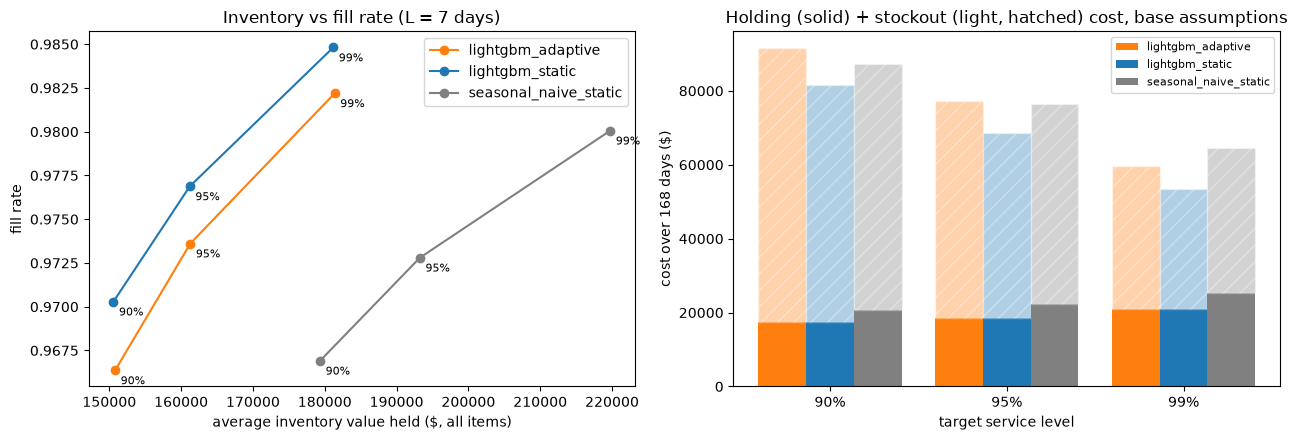

In [8]:
COLORS = {f'{MODEL}_static': 'tab:blue', f'{MODEL}_adaptive': 'tab:orange', 'seasonal_naive_static': 'grey'}
s = summary.reset_index()
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for policy, g in s.groupby('policy'):
    axes[0].plot(g['avg_inventory_value'], g['fill_rate'], marker='o', color=COLORS[policy], label=policy)
    for _, r in g.iterrows():
        axes[0].annotate(f"{r['service_level']:.0%}", (r['avg_inventory_value'], r['fill_rate']), fontsize=8,
                         xytext=(4, -10), textcoords='offset points')
axes[0].set(xlabel='average inventory value held ($, all items)', ylabel='fill rate',
            title=f'Inventory vs fill rate (L = {BASE_L} days)')
axes[0].legend()
x = np.arange(len(SERVICE_LEVELS))
for i, (policy, g) in enumerate(s.groupby('policy')):
    axes[1].bar(x + i * 0.27, g['holding_cost'], 0.27, color=COLORS[policy], label=policy)
    axes[1].bar(x + i * 0.27, g['stockout_cost'], 0.27, bottom=g['holding_cost'], color=COLORS[policy],
                alpha=0.35, hatch='//', edgecolor='white')
axes[1].set_xticks(x + 0.27, [f"{sl:.0%}" for sl in SERVICE_LEVELS])
axes[1].set(xlabel='target service level', ylabel='cost over 168 days ($)',
            title='Holding (solid) + stockout (light, hatched) cost, base assumptions')
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.savefig("../outputs/figures/inventory_tradeoff.png", dpi=120)
plt.show()